# 📊 AprovaEdu Analytics — Persistência e Retenção (Base Completa)

Aprofundamento do achado central do `05_analise_completa.ipynb`. Lá identifiquei que o
único fator com sinal era a **amplitude de matrículas** (aprovados cursam ~25% mais).
Aqui investigo **por quê** — e a resposta muda a leitura: o que importa não é quantas
matérias o aluno faz, e sim **quantos anos ele permanece**.

Três perguntas guiam o notebook:
1. A permanência (nº de anos cursados) se associa à aprovação? Quanto?
2. O efeito é real ou só mecânico (mais anos = mais tentativas de vestibular)?
3. O fator "nº de matrículas" sobrevive quando controlo a permanência?

E, de quebra: churn (cancelamentos), bolsa e a evolução do aluno nos simulados.

## 1. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
FINAL = ROOT / "data" / "final"

matriculas = pd.read_parquet(FINAL / "matriculas.parquet")
aprovacoes = pd.read_parquet(FINAL / "aprovacoes.parquet")
resultados = pd.read_parquet(FINAL / "resultados_sim.parquet")

aprovados = set(aprovacoes["aluno_id"])

PAL = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
BLUE, AQUA, ORANGE, MUTEDBAR = PAL[0], PAL[1], PAL[7], "#898781"
INK, INK2, MUTED, GRID, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 11,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110,
})

# tabela aluno × (anos cursados, nº de matrículas, aprovado)
alunos = matriculas.groupby("aluno_id").agg(
    anos=("ano", "nunique"), n_matriculas=("matricula_id", "count"))
alunos["aprovado"] = alunos.index.isin(aprovados)
print(f"{len(alunos)} alunos | distribuição de anos cursados: "
      f"{alunos['anos'].value_counts().sort_index().to_dict()}")

800 alunos | distribuição de anos cursados: {1: 602, 2: 174, 3: 24}


## 2. Persistência × aprovação — o sinal mais forte do dataset

In [2]:
persist = alunos.groupby("anos")["aprovado"].agg(taxa="mean", alunos="count")
persist["taxa_%"] = (persist["taxa"] * 100).round(1)
persist[["alunos", "taxa_%"]]

,alunos,taxa_%
anos,,
1,602,31.6
2,174,54.6
3,24,87.5


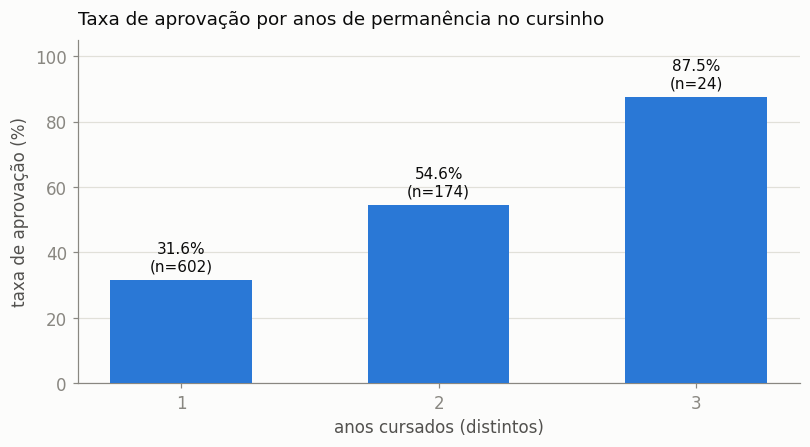

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
x = persist.index.astype(int)
b = ax.bar(x, persist["taxa_%"], color=BLUE, width=0.55, zorder=3)
for bar, v, n in zip(b, persist["taxa_%"], persist["alunos"]):
    ax.annotate(f"{v:.1f}%\n(n={n})", (bar.get_x() + bar.get_width()/2, v),
                textcoords="offset points", xytext=(0, 6), ha="center", color=INK, fontsize=10)
ax.set_title("Taxa de aprovação por anos de permanência no cursinho", color=INK,
             fontsize=12, loc="left", pad=10)
ax.set_xlabel("anos cursados (distintos)"); ax.set_ylabel("taxa de aprovação (%)")
ax.set_xticks(list(x)); ax.set_ylim(0, 105); ax.grid(axis="x", visible=False)
fig.tight_layout(); plt.show()

**31,6% → 54,6% → 87,5%.** A permanência tem relação monotônica e forte com a aprovação —
nenhum outro fator do dataset chega perto.

## 3. O efeito é real ou mecânico?

Cuidado antes de comemorar: quem cursa 2 anos tem **2 tentativas** de vestibular. Mesmo
sem nenhum ganho de aprendizado, a taxa *acumulada* subiria por pura repetição de
tentativas. O benchmark mecânico é `1 − (1 − p)^k`, com `p` = taxa de quem cursa 1 ano.

In [4]:
p1 = alunos.loc[alunos["anos"] == 1, "aprovado"].mean()
comp = pd.DataFrame({
    "anos": [1, 2, 3],
    "observado_%": [persist.loc[k, "taxa"] * 100 for k in [1, 2, 3]],
    "mecanico_%": [(1 - (1 - p1) ** k) * 100 for k in [1, 2, 3]],
}).round(1)
comp["excedente_pp"] = (comp["observado_%"] - comp["mecanico_%"]).round(1)
comp

,anos,observado_%,mecanico_%,excedente_pp
0,1,31.6,31.6,0.0
1,2,54.6,53.2,1.4
2,3,87.5,67.9,19.6


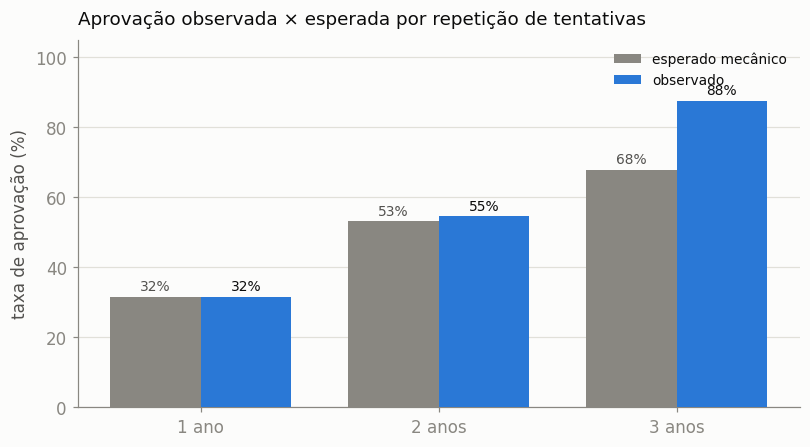

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
x = np.arange(3); w = 0.38
ax.bar(x - w/2, comp["mecanico_%"], width=w, color=MUTEDBAR, label="esperado mecânico", zorder=3)
ax.bar(x + w/2, comp["observado_%"], width=w, color=BLUE, label="observado", zorder=3)
for xi, (m, o) in enumerate(zip(comp["mecanico_%"], comp["observado_%"])):
    ax.annotate(f"{m:.0f}%", (xi - w/2, m), textcoords="offset points", xytext=(0, 4),
                ha="center", color=INK2, fontsize=9)
    ax.annotate(f"{o:.0f}%", (xi + w/2, o), textcoords="offset points", xytext=(0, 4),
                ha="center", color=INK, fontsize=9)
ax.set_title("Aprovação observada × esperada por repetição de tentativas", color=INK,
             fontsize=12, loc="left", pad=10)
ax.set_xticks(x); ax.set_xticklabels(["1 ano", "2 anos", "3 anos"])
ax.set_ylabel("taxa de aprovação (%)"); ax.set_ylim(0, 105)
ax.grid(axis="x", visible=False); ax.legend(frameon=False, fontsize=9)
fig.tight_layout(); plt.show()

**Leitura honesta:** em 2 anos, o observado (54,6%) fica colado no mecânico (53,2%) — é
basicamente o efeito de ter duas tentativas. Em **3 anos**, porém, o observado (87,5%)
**excede o mecânico (67,9%) em ~20 p.p.** — sinal de ganho acumulado além da repetição.
Ressalva: o grupo de 3 anos tem **n=24**, então o excedente é indicativo, não definitivo.
Para o negócio, a distinção importa menos: **em qualquer decomposição, reter o aluno
aumenta a chance de aprovação eventual.**

## 4. O fator "nº de matrículas" era um disfarce da persistência

No `05`, o nº de matrículas era o único fator que separava aprovados (13,4 vs 10,8).
Teste do confundidor: se matrículas importassem por si, deveriam separar os grupos
**dentro** de quem cursou o mesmo nº de anos.

In [6]:
print("matrículas médias por anos cursados:",
      alunos.groupby("anos")["n_matriculas"].mean().round(1).to_dict())

um_ano = alunos[alunos["anos"] == 1].copy()
print("\nSÓ quem cursou 1 ano:")
print("  n_matriculas (aprovado vs não):",
      um_ano.groupby("aprovado")["n_matriculas"].mean().round(2).to_dict())

um_ano["faixa"] = pd.cut(um_ano["n_matriculas"], [0, 8, 10, 12, 99],
                         labels=["≤8", "9–10", "11–12", "13+"])
um_ano.groupby("faixa", observed=True)["aprovado"].agg(taxa="mean", alunos="count").round(3)

matrículas médias por anos cursados: {1: 9.2, 2: 18.6, 3: 28.2}

SÓ quem cursou 1 ano:
  n_matriculas (aprovado vs não): {False: 9.2, True: 9.22}


,taxa,alunos
faixa,,
≤8,0.294,201
9–10,0.346,272
11–12,0.287,129


**Confirmado: era um proxy.** Quem fica mais anos acumula mais matrículas (9,2 → 18,6 →
28,2), mas **dentro de quem cursou 1 ano**, aprovados e não aprovados têm o mesmo volume
(9,2 vs 9,2) e a taxa não cresce com a faixa de matrículas. O fator real é a
**permanência**, não a quantidade de matérias por ano.

> Isso corrige a leitura do `05` (e a recomendação de "amplitude de matrículas"): a
> alavanca é **rematrícula/retenção entre anos** — pacotes plurianuais, acompanhamento de
> quem termina o ano sem aprovação, campanha de retorno — e não empilhar matérias no
> mesmo ano. Também explica o coeficiente dominante do modelo (`n_matriculas`).

## 5. Complementos: churn, bolsa e evolução nos simulados

In [7]:
print("status das matrículas:",
      matriculas["status_matricula"].value_counts(normalize=True).round(3).to_dict())
canc = (matriculas.assign(c=matriculas["status_matricula"].eq("Cancelada"))
        .groupby("ano")["c"].mean().mul(100).round(1))
print("cancelamento por ano (%):", canc.to_dict())

tx_canc = (matriculas.assign(c=matriculas["status_matricula"].eq("Cancelada"))
           .groupby("aluno_id")["c"].mean())
d = pd.DataFrame({"txc": tx_canc}); d["aprovado"] = d.index.isin(aprovados)
print("cancelamento médio por aluno (aprovado vs não):",
      d.groupby("aprovado")["txc"].mean().mul(100).round(1).to_dict())

bolsa = matriculas.groupby("aluno_id")["bolsa_percentual"].mean()
db = pd.DataFrame({"bolsa": bolsa}); db["aprovado"] = db.index.isin(aprovados)
print("bolsa média (aprovado vs não):", db.groupby("aprovado")["bolsa"].mean().round(1).to_dict())

status das matrículas: {'Concluída': 0.699, 'Ativa': 0.184, 'Cancelada': 0.061, 'Trancada': 0.035, 'Não informado': 0.02}
cancelamento por ano (%): {2021: 6.2, 2022: 5.4, 2023: 6.5, 2024: 6.2, 2025: 6.0}
cancelamento médio por aluno (aprovado vs não): {False: 6.4, True: 5.8}
bolsa média (aprovado vs não): {False: 17.0, True: 16.4}


In [8]:
r = resultados.dropna(subset=["nota"]).sort_values("inicio_simulado")
g = r.groupby("aluno_id")["nota"]
evo = pd.DataFrame({"primeira": g.first(), "ultima": g.last(), "n": g.size()})
evo = evo[evo["n"] >= 5]
evo["delta"] = evo["ultima"] - evo["primeira"]
evo["aprovado"] = evo.index.isin(aprovados)
evo.groupby("aprovado")["delta"].agg(delta_medio="mean", alunos="count").round(2)

,delta_medio,alunos
aprovado,,
False,0.53,494
True,1.75,306


- **Churn é baixo e estável**: ~6% de cancelamento ao ano, sem relação com o desfecho
  (6,4% vs 5,8%) — cancelamento não é o problema da rede.
- **Bolsa não se associa à aprovação** (17,0% vs 16,4% de desconto médio) — bolsa serve à
  captação/inclusão, não à conversão.
- **Evolução nos simulados**: da primeira à última prova, aprovados melhoram **+1,75
  pontos** contra +0,53 dos não aprovados — pequeno em valor absoluto, mas ~3× maior:
  consistente com ganho de aprendizado de quem persiste.

## 6. Conclusão — a recomendação nº 1 muda

A análise de persistência **reordena as recomendações** para a coordenação:

1. **Retenção é a alavanca nº 1.** A taxa de aprovação eventual salta de 31,6% (1 ano)
   para 54,6% (2 anos) e 87,5% (3 anos). Mesmo descontando o efeito mecânico das
   tentativas extras, permanecer compensa — e no 3º ano há sinal de ganho além da
   repetição. Ações: pacotes plurianuais, contato ativo com quem encerra o ano sem
   aprovação, condições de rematrícula.
2. **"Mais matérias no mesmo ano" não é a alavanca.** O volume de matrículas só
   separava aprovados por ser proxy da permanência — dentro do mesmo nº de anos, não
   faz diferença. (Correção explícita da leitura anterior — o dado mandou, eu obedeci.)
3. **Cancelamento e bolsa não são o problema** — churn baixo e estável; bolsa sem
   relação com o desfecho.

Limitações que registro: análise observacional (persistir pode selecionar alunos mais
determinados); grupo de 3 anos pequeno (n=24); e o "efeito tentativa" responde por boa
parte do ganho no 2º ano. A recomendação de instrumentar **coortes** (ingresso ×
vestibular) segue valendo para separar seleção de causalidade.